In [ ]:
sentences = [
    ["i", "love", "machine", "learning"],
    ["i", "love", "data", "science"],
    ["word", "embeddings", "are", "amazing"],
    ["deep", "learning", "is", "fun"],
    ["i", "like", "machine", "learning"],
    ["you", "like", "data", "science"]
]


In [ ]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

print("Model trained!")

Model trained!


In [ ]:
model.save("my_word2vec.model")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os
print(os.listdir())

['.config', 'my_word2vec.model', 'sample_data']


In [ ]:
from gensim.models import Word2Vec
model = Word2Vec.load("my_word2vec.model")

print("Model loaded!")

Model loaded!


In [ ]:
from numpy import dot
from numpy.linalg import norm

def cosine_sim(a, b):
    v1 = model.wv[a]
    v2 = model.wv[b]
    return dot(v1, v2)/(norm(v1)*norm(v2))

print(cosine_sim("love", "like"))

0.1459506


In [ ]:
!pip install gensim python-crfsuite fasttext flashtext && pip install hazm --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached flashtext-2.7.tar.gz (14 kB)
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.4 MB/s eta 0:00:00
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498213 sha256=d8d953eb2b61e94765a4b4c6f7a0177c08c214d7dd025d4a8bf5be8f7d8f0b02
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=031d35964230c593c8768a02595002457bb58cb97c6decbeb4fbcd204427c763
  Stored in directory: /root/.cache/pip/wheels/8c/24/da/4d994d7a27cfc73

In [ ]:
!pip install python-Levenshtein fuzzywuzzy

  Using cached python_levenshtein-0.27.3-py3-none-any.whl.metadata (3.9 kB)
  Using cached fuzzywuzzy-0.18.0-py2.py3-none-any.whl.metadata (4.9 kB)
  Using cached levenshtein-0.27.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (3.7 kB)
  Using cached rapidfuzz-3.14.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.4 MB/s eta 0:00:00


In [38]:
import numpy as np
from hazm import Normalizer, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from fuzzywuzzy import fuzz
import Levenshtein
import matplotlib.pyplot as plt
import seaborn as sns

import arabic_reshaper
from bidi.algorithm import get_display
from sklearn.manifold import TSNE

In [39]:
plt.rcParams["font.family"] = "DejaVu Sans"

def fa(text: str) -> str:
    """اصلاح نوشتار فارسی برای نمایش در matplotlib (چسباندن + راست‌به‌چپ)"""
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    return bidi_text

In [40]:
sentences = [
    "من فوتبال دوست دارم",
    "او فوتبال را خیلی دوست دارد",
    "هوا امروز بارانی است",
    "من عاشق یادگیری ماشین هستم",
    "یادگیری ماشین شاخه‌ای از هوش مصنوعی است"
]

normalizer = Normalizer()
sent_clean = [normalizer.normalize(s) for s in sentences]
print("جملات نرمال‌شده:")
for s in sent_clean:
    print(" -", s)


جملات نرمال‌شده:
 - من فوتبال دوست دارم
 - او فوتبال را خیلی دوست دارد
 - هوا امروز بارانی است
 - من عاشق یادگیری ماشین هستم
 - یادگیری ماشین شاخه‌ای از هوش مصنوعی است


In [41]:
tokenized = [word_tokenize(s) for s in sent_clean]
print("\nتوکن‌ها:")
for t in tokenized:
    print(t)


توکن‌ها:
['من', 'فوتبال', 'دوست', 'دارم']
['او', 'فوتبال', 'را', 'خیلی', 'دوست', 'دارد']
['هوا', 'امروز', 'بارانی', 'است']
['من', 'عاشق', 'یادگیری', 'ماشین', 'هستم']
['یادگیری', 'ماشین', 'شاخه\u200cای', 'از', 'هوش', 'مصنوعی', 'است']


In [43]:
model = Word2Vec(
    tokenized,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)
print("\n✅ مدل Word2Vec آموزش داده شد.")


✅ مدل Word2Vec آموزش داده شد.


In [45]:
def cos_sim(word1, word2):
    return cosine_similarity(
        [model.wv[word1]],
        [model.wv[word2]]
    )[0][0]

print("\n🔹 شباهت کسینوسی بین چند کلمه موجود در واژگان:")
print("شباهت فوتبال و دوست:", cos_sim("فوتبال", "دوست"))
print("شباهت یادگیری و ماشین:", cos_sim("یادگیری", "ماشین"))
print("شباهت فوتبال و بارانی:", cos_sim("فوتبال", "بارانی"))


🔹 شباهت کسینوسی بین چند کلمه موجود در واژگان:
شباهت فوتبال و دوست: -0.0446171
شباهت یادگیری و ماشین: -0.010756587
شباهت فوتبال و بارانی: 0.15017743


In [46]:
def safe_cos_sim(w1, w2):
    if w1 not in model.wv or w2 not in model.wv:
        print(f"⚠ یکی از کلمات «{w1}» یا «{w2}» در واژگان مدل نیست.")
        return None
    sim = cos_sim(w1, w2)
    print(f"cos_sim({w1}, {w2}) = {sim:.3f}")
    return sim

# مثال:
safe_cos_sim("ماشین", "خودرو")  # خودرو در واژگان نیست

⚠ یکی از کلمات «ماشین» یا «خودرو» در واژگان مدل نیست.


In [47]:
def euclidean(w1, w2):
    return np.linalg.norm(model.wv[w1] - model.wv[w2])

def manhattan(w1, w2):
    return np.sum(np.abs(model.wv[w1] - model.wv[w2]))

print("\n🔹 فاصله‌ها بین چند کلمه:")
print("Euclidean(یادگیری, ماشین):", euclidean("یادگیری","ماشین"))
print("Manhattan(یادگیری, ماشین):", manhattan("یادگیری","ماشین"))


🔹 فاصله‌ها بین چند کلمه:
Euclidean(یادگیری, ماشین): 0.08142832
Manhattan(یادگیری, ماشین): 0.666776


In [48]:
print("\n🔹 فاصله‌ی ویرایشی (Levenshtein):")
print("کتاب ↔ کباب =", Levenshtein.distance("کتاب","کباب"))
print("سلام ↔ سالم =", Levenshtein.distance("سلام","سالم"))
print("ماشن ↔ ماشین =", Levenshtein.distance("ماشن","ماشین"))


🔹 فاصله‌ی ویرایشی (Levenshtein):
کتاب ↔ کباب = 1
سلام ↔ سالم = 2
ماشن ↔ ماشین = 1


In [49]:
def jaccard(s1, s2):
    set1, set2 = set(word_tokenize(s1)), set(word_tokenize(s2))
    return len(set1 & set2) / len(set1 | set2)

print("\n🔹 Jaccard similarity بین جملات:")
print("جمله ۱ و ۲:", jaccard(sent_clean[0], sent_clean[1]))
print("جمله ۱ و ۴:", jaccard(sent_clean[0], sent_clean[3]))


🔹 Jaccard similarity بین جملات:
جمله ۱ و ۲: 0.25
جمله ۱ و ۴: 0.125


In [50]:
print("\n🔹 Fuzzy matching:")
print("هوش مصنوعی ↔ هوش مسنوعی =", fuzz.ratio("هوش مصنوعی", "هوش مسنوعی"))
print("یادگیری ماشین ↔ ماشین لرنینگ =", fuzz.partial_ratio("یادگیری ماشین", "ماشین لرنینگ"))



🔹 Fuzzy matching:
هوش مصنوعی ↔ هوش مسنوعی = 90
یادگیری ماشین ↔ ماشین لرنینگ = 43


In [51]:
def sentence_vector(sentence):
    words = word_tokenize(sentence)
    vectors = [model.wv[w] for w in words if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

vecs = [sentence_vector(s) for s in sent_clean]
vecs = np.array(vecs)

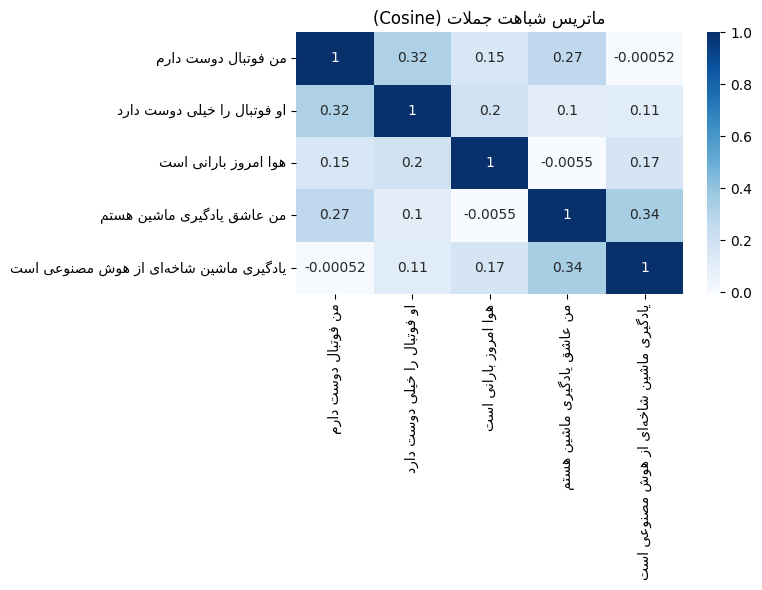

In [52]:
sim_matrix = cosine_similarity(vecs)

plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_matrix, annot=True, cmap="Blues",
    xticklabels=[fa(s) for s in sent_clean],
    yticklabels=[fa(s) for s in sent_clean]
)
plt.title(fa("ماتریس شباهت جملات (Cosine)"))
plt.tight_layout()
plt.show()

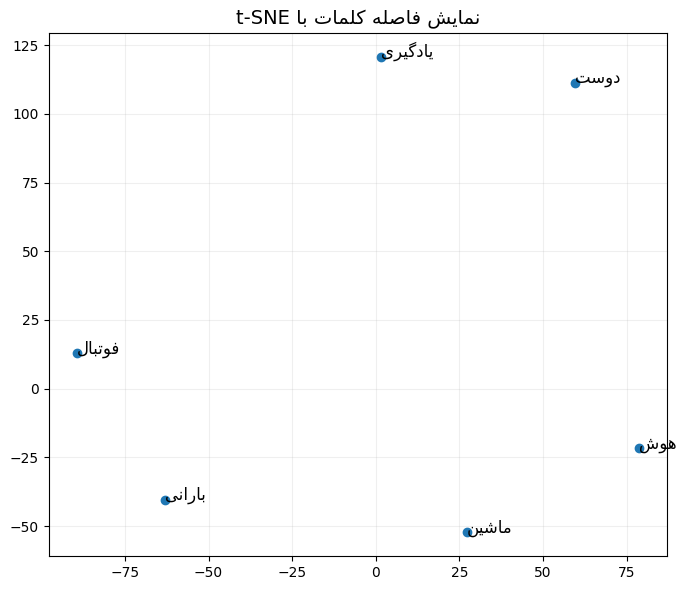

In [53]:
words = ["فوتبال", "ماشین", "هوش", "یادگیری", "بارانی", "دوست"]

# فقط کلماتی را نگه می‌داریم که حتماً در واژگان هستند
words = [w for w in words if w in model.wv]
vectors_words = np.array([model.wv[w] for w in words])

tsne = TSNE(n_components=2, random_state=42, perplexity=3)
reduced = tsne.fit_transform(vectors_words)

plt.figure(figsize=(7, 6))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, w in enumerate(words):
    plt.annotate(
        fa(w),
        xy=(reduced[i, 0], reduced[i, 1]),
        fontsize=12
    )

plt.title(fa("نمایش فاصلهٔ کلمات با t-SNE"), fontsize=14)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()